## Métricas de Qualidade - Backend (SonarCloud)

Esta seção apresenta a análise automatizada da saúde técnica do backend, utilizando dados extraídos via API do **SonarCloud**. O dashboard utiliza conceitos avançados de **Engenharia de Software** para transformar métricas brutas em indicadores de decisão.

### Definição das Métricas

* **ncloc (Lines of Code):** Quantidade de linhas de código lógico, utilizada como base para o cálculo de densidade.
* **Ratings (A-E):** Avaliação qualitativa de **Reliability** (Confiabilidade), **Security** (Segurança) e **Maintainability** (Manutenibilidade).
* **Issues por Densidade (KLOC):** Bugs, Vulnerabilidades e Code Smells calculados a cada 1.000 linhas de código. Isso permite uma comparação justa entre diferentes tamanhos de projeto.
* **Coverage:** Percentual de linhas protegidas por testes unitários e de integração.

---

### Análise e Interpretação dos Resultados

#### 1. Índice de Qualidade Geral (Quality Score)
Diferente de dashboards comuns, o nosso **Quality Score** é um indicador composto e normalizado por densidade, seguindo a fórmula:

$$QualityScore = (Cov_{norm} \cdot 0.35) + (Vuln_{norm} \cdot 0.25) + (Bugs_{norm} \cdot 0.20) + (Smells_{norm} \cdot 0.10) + (Dup_{norm} \cdot 0.10)$$

* **Nível ALTA (>= 0.8):** Alta maturidade técnica. O projeto equilibra segurança, testes e manutenibilidade.
* **Nível MÉDIA (0.5 - 0.79):** Alerta para o acúmulo de dívida técnica ou queda na cobertura de testes.
* **Nível BAIXA (< 0.5):** Risco crítico. Necessidade de interrupção para refatoração e correção de vulnerabilidades.

#### 2. Densidade de Issues (KLOC)
O gráfico de **Densidade** é o nosso principal termômetro de qualidade. Em vez de olhar apenas o número absoluto de bugs, avaliamos se a frequência de erros está aumentando proporcionalmente ao tamanho do código.
* **Vulnerabilidades:** Possuem o maior peso negativo, pois comprometem a integridade do sistema.
* **Bugs:** Indicam falhas na lógica de negócio que devem ser mitigadas com melhores práticas de QA.

#### 3. Qualidade Estrutural e Cobertura
A análise visual de pizza e barras foca no equilíbrio do **Pipeline de CI**:
* **Testes:** Buscamos manter a cobertura acima de 80% para garantir refatorações seguras.
* **Duplicação:** Monitoramos para manter o código enxuto, respeitando o princípio **DRY** (*Don't Repeat Yourself*).

---
> A transição para uma análise baseada em **Densidade (KLOC)** segue os padrões de mercado para métricas de software (ISO/IEC 25010). Isso garante que o dashboard permaneça útil e preciso à medida que o repositório `RetinaScan-Api` cresce, evitando que números absolutos mascarem a real qualidade do produto.

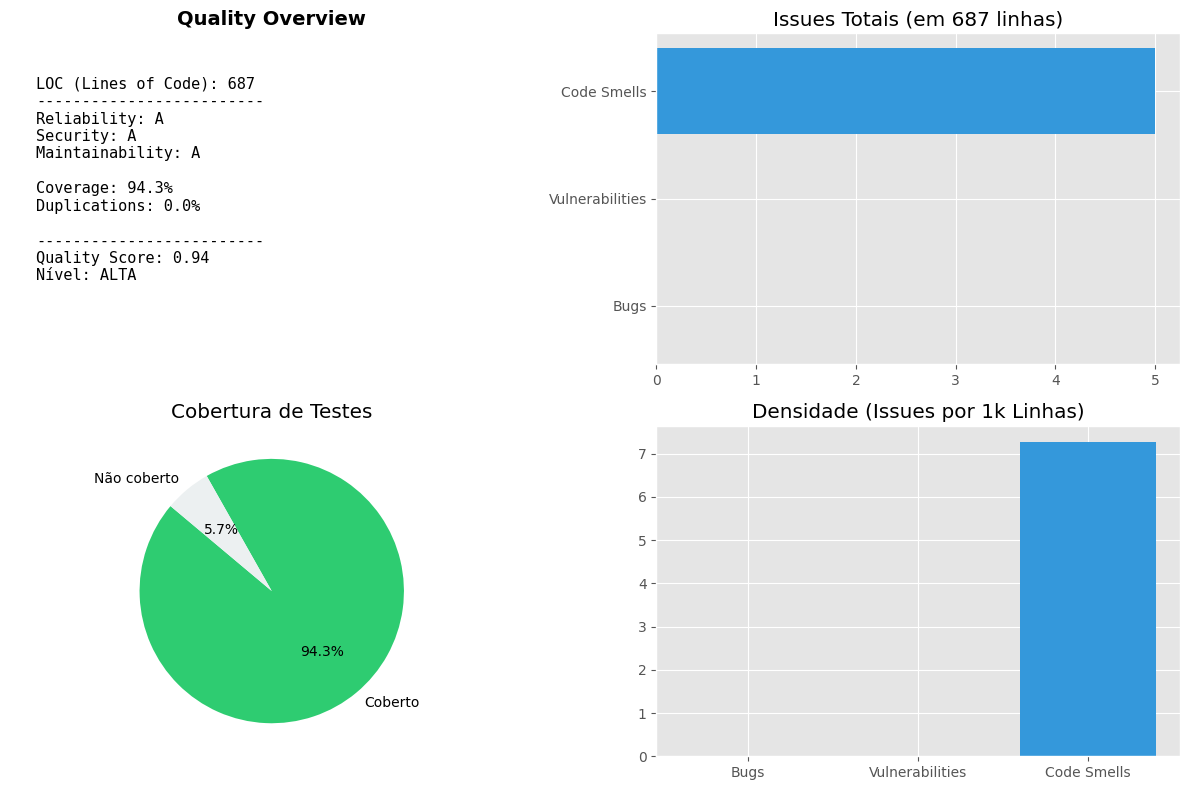

In [5]:
# @title
import requests
import matplotlib.pyplot as plt

project_key = "fga-eps-mds_2026-1-RetinaScan-Api"
url = "https://sonarcloud.io/api/measures/component"

params = {
    "component": project_key,
    "metricKeys": "bugs,vulnerabilities,code_smells,coverage,duplicated_lines_density,reliability_rating,security_rating,sqale_rating,ncloc"
}

try:
    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()

    measures = data.get("component", {}).get("measures", [])
    metrics = {item["metric"]: float(item.get("value", 0)) for item in measures}
except Exception as e:
    print(f"Erro ao obter dados: {e}")
    metrics = {}

ncloc = metrics.get("ncloc", 1)
bugs = metrics.get("bugs", 0)
vulnerabilities = metrics.get("vulnerabilities", 0)
smells = metrics.get("code_smells", 0)
coverage = metrics.get("coverage", 0)
duplication = metrics.get("duplicated_lines_density", 0)

issues = [bugs, vulnerabilities, smells]
issues_labels = ["Bugs", "Vulnerabilities", "Code Smells"]

def rating_to_letter(value):
    mapping = {1: "A", 2: "B", 3: "C", 4: "D", 5: "E"}
    return mapping.get(int(value), "F")

ratings = {
    "Reliability": rating_to_letter(metrics.get("reliability_rating", 1)),
    "Security": rating_to_letter(metrics.get("security_rating", 1)),
    "Maintainability": rating_to_letter(metrics.get("sqale_rating", 1))
}

kloc = ncloc / 1000

norm_bugs = 1 - min((bugs / kloc) / 5, 1) if kloc > 0 else 1
norm_vulnerabilities = 1 - min((vulnerabilities / kloc) / 2, 1) if kloc > 0 else 1
norm_smells = 1 - min((smells / kloc) / 20, 1) if kloc > 0 else 1

norm_coverage = coverage / 100
norm_duplication = 1 - (duplication / 100)

quality_score = (
    norm_coverage * 0.35 +
    norm_vulnerabilities * 0.25 +
    norm_bugs * 0.20 +
    norm_smells * 0.10 +
    norm_duplication * 0.10
)

if quality_score >= 0.8:
    quality_label = "ALTA"
elif quality_score >= 0.5:
    quality_label = "MÉDIA"
else:
    quality_label = "BAIXA"

plt.style.use('ggplot')
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].axis('off')
axs[0, 0].set_title("Quality Overview", fontsize=14, fontweight='bold')

kpi_text = f"""
LOC (Lines of Code): {int(ncloc)}
{'-'*25}
Reliability: {ratings['Reliability']}
Security: {ratings['Security']}
Maintainability: {ratings['Maintainability']}

Coverage: {coverage:.1f}%
Duplications: {duplication:.1f}%

{'-'*25}
Quality Score: {quality_score:.2f}
Nível: {quality_label}
"""
axs[0, 0].text(0.05, 0.2, kpi_text, fontsize=11, family='monospace')

axs[0, 1].barh(issues_labels, issues, color=['#e74c3c', '#c0392b', '#3498db'])
axs[0, 1].set_title(f"Issues Totais (em {int(ncloc)} linhas)")

axs[1, 0].pie(
    [coverage, max(0, 100 - coverage)],
    labels=["Coberto", "Não coberto"],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#ecf0f1'],
    startangle=140
)
axs[1, 0].set_title("Cobertura de Testes")

densities = [bugs/kloc, vulnerabilities/kloc, smells/kloc]
axs[1, 1].bar(issues_labels, densities, color=['#e74c3c', '#c0392b', '#3498db'])
axs[1, 1].set_title("Densidade (Issues por 1k Linhas)")

plt.tight_layout()
plt.show()

## Métricas de Qualidade - Frontend (SonarCloud)

Esta seção detalha a qualidade técnica da interface do **RetinaScan-Web**. No desenvolvimento frontend, manter a manutenibilidade e a baixa densidade de *Code Smells* é crucial para garantir uma UI fluida e livre de efeitos colaterais.

### Métricas Estratégicas

* **Maintainability (Manutenibilidade):** Essencial para o frontend, avalia a facilidade de evolução dos componentes e hooks.
* **Security & Vulnerabilities:** Monitora riscos em dependências e manipulação de dados no lado do cliente.
* **Densidade por KLOC:** Normaliza a quantidade de problemas pelo tamanho da base de código (Lines of Code), permitindo medir a eficiência do desenvolvimento à medida que a aplicação cresce.

---

### Análise do Quality Score (Front)

O cálculo do score segue o mesmo rigor aplicado ao backend, garantindo que o projeto mantenha uma barra de qualidade única:

$$QualityScore = (Cov_{norm} \cdot 0.35) + (Vuln_{norm} \cdot 0.25) + (Bugs_{norm} \cdot 0.20) + (Smells_{norm} \cdot 0.10) + (Dup_{norm} \cdot 0.10)$$

* **Foco em Cobertura:** Para o frontend, priorizamos a cobertura de componentes críticos e fluxos de usuário, visando mitigar bugs de interface que afetam diretamente a experiência do usuário.
* **Saúde Estrutural:** A baixa duplicação de código reflete o uso eficiente de componentes reutilizáveis e o respeito aos padrões de design de software.


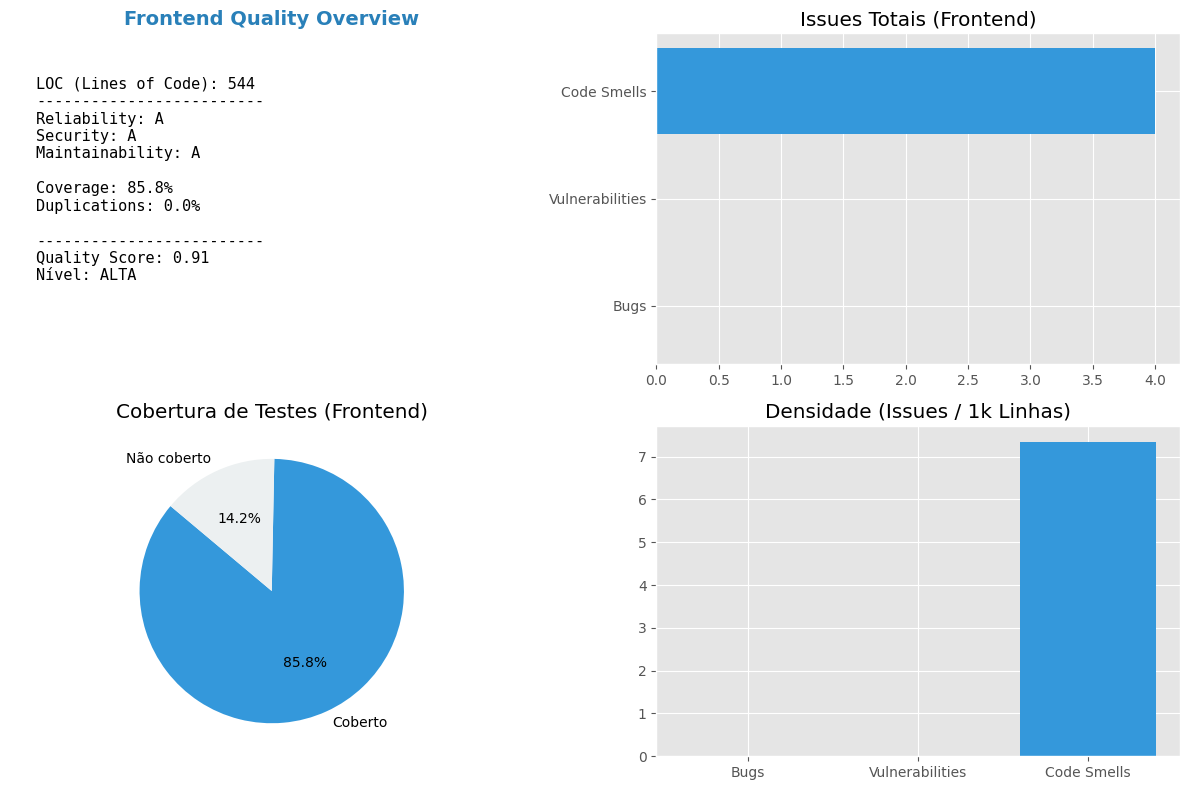

In [10]:
# @title
import requests
import matplotlib.pyplot as plt


project_key = "fga-eps-mds_2026-1-RetinaScan-Web"
url = "https://sonarcloud.io/api/measures/component"

params = {
    "component": project_key,
    "metricKeys": "bugs,vulnerabilities,code_smells,coverage,duplicated_lines_density,reliability_rating,security_rating,sqale_rating,ncloc"
}

try:
    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()

    measures = data.get("component", {}).get("measures", [])
    metrics = {item["metric"]: float(item.get("value", 0)) for item in measures}
except Exception as e:
    print(f"Erro ao obter dados do Frontend: {e}")
    metrics = {}

ncloc = metrics.get("ncloc", 1)
bugs = metrics.get("bugs", 0)
vulnerabilities = metrics.get("vulnerabilities", 0)
smells = metrics.get("code_smells", 0)
coverage = metrics.get("coverage", 0)
duplication = metrics.get("duplicated_lines_density", 0)

issues = [bugs, vulnerabilities, smells]
issues_labels = ["Bugs", "Vulnerabilities", "Code Smells"]

def rating_to_letter(value):
    mapping = {1: "A", 2: "B", 3: "C", 4: "D", 5: "E"}
    return mapping.get(int(value), "F")

ratings = {
    "Reliability": rating_to_letter(metrics.get("reliability_rating", 1)),
    "Security": rating_to_letter(metrics.get("security_rating", 1)),
    "Maintainability": rating_to_letter(metrics.get("sqale_rating", 1))
}

kloc = ncloc / 1000

norm_bugs = 1 - min((bugs / kloc) / 5, 1) if kloc > 0 else 1
norm_vulnerabilities = 1 - min((vulnerabilities / kloc) / 2, 1) if kloc > 0 else 1
norm_smells = 1 - min((smells / kloc) / 20, 1) if kloc > 0 else 1
norm_coverage = coverage / 100
norm_duplication = 1 - (duplication / 100)

quality_score = (
    norm_coverage * 0.35 +
    norm_vulnerabilities * 0.25 +
    norm_bugs * 0.20 +
    norm_smells * 0.10 +
    norm_duplication * 0.10
)

quality_label = "ALTA" if quality_score >= 0.8 else "MÉDIA" if quality_score >= 0.5 else "BAIXA"

plt.style.use('ggplot')
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].axis('off')
axs[0, 0].set_title("Frontend Quality Overview", fontsize=14, fontweight='bold', color='#2980b9')

kpi_text = f"""
LOC (Lines of Code): {int(ncloc)}
{'-'*25}
Reliability: {ratings['Reliability']}
Security: {ratings['Security']}
Maintainability: {ratings['Maintainability']}

Coverage: {coverage:.1f}%
Duplications: {duplication:.1f}%

{'-'*25}
Quality Score: {quality_score:.2f}
Nível: {quality_label}
"""
axs[0, 0].text(0.05, 0.2, kpi_text, fontsize=11, family='monospace')

axs[0, 1].barh(issues_labels, issues, color=['#e74c3c', '#c0392b', '#3498db'])
axs[0, 1].set_title(f"Issues Totais (Frontend)")

axs[1, 0].pie(
    [coverage, max(0, 100 - coverage)],
    labels=["Coberto", "Não coberto"],
    autopct='%1.1f%%',
    colors=['#3498db', '#ecf0f1'],
    startangle=140
)
axs[1, 0].set_title("Cobertura de Testes (Frontend)")

densities = [bugs/kloc, vulnerabilities/kloc, smells/kloc]
axs[1, 1].bar(issues_labels, densities, color=['#e74c3c', '#c0392b', '#3498db'])
axs[1, 1].set_title("Densidade (Issues / 1k Linhas)")

plt.tight_layout()
plt.show()

## Velocity Chart (Produtividade do Time)

O gráfico de **Velocity** é uma métrica fundamental do framework Scrum, utilizada para medir a taxa de entrega de valor da equipe ao longo das sprints.

### O que estamos analisando?
* **Planejado (Commitment):** A quantidade de trabalho que a equipe se comprometeu a realizar durante a Sprint Planning.
* **Entregue (Velocity):** O trabalho efetivamente concluído e que atende à "Definição de Pronto" (DoD).

### Interpretação
Este gráfico permite observar a **maturidade da equipe**. Nas primeiras sprints, é comum haver uma grande diferença entre o planejado e o entregue. Com o tempo, a tendência é que a equipe aprenda sua real capacidade, tornando as estimativas mais precisas e a velocidade mais constante.

> **Nota:** Os dados de produtividade são consolidados manualmente a partir do **ZenHub**, considerando o fechamento de cada ciclo de entrega.

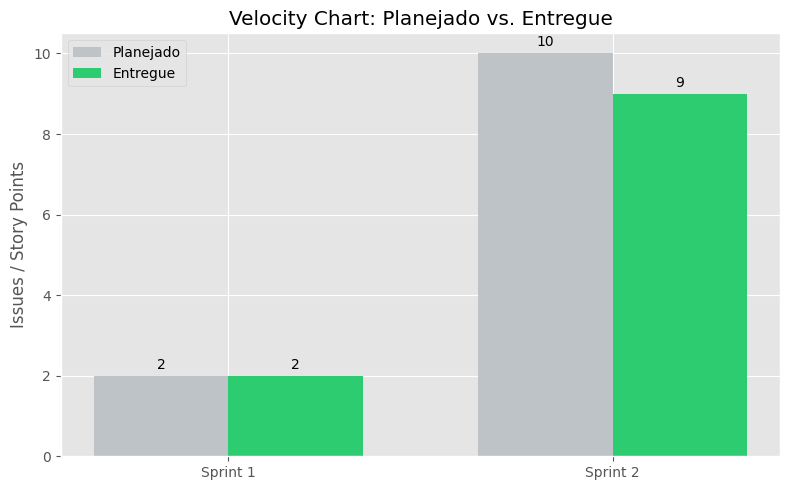

In [7]:
# @title
import matplotlib.pyplot as plt
import numpy as np

sprints = ["Sprint 1", "Sprint 2"]
planned = [2, 10]
achieved = [2, 9]

x = np.arange(len(sprints))
width = 0.35

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(8, 5))

rects1 = ax.bar(x - width/2, planned, width, label='Planejado', color='#bdc3c7')
rects2 = ax.bar(x + width/2, achieved, width, label='Entregue', color='#2ecc71')

ax.set_ylabel('Issues / Story Points')
ax.set_title('Velocity Chart: Planejado vs. Entregue')
ax.set_xticks(x)
ax.set_xticklabels(sprints)
ax.legend()

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

plt.tight_layout()
plt.show()

## Gestão de Valor Agregado (EVM) Ágil

O **EVM (Earned Value Management)** é uma metodologia que integra escopo, cronograma e recursos para medir o desempenho e o progresso do projeto. No contexto ágil, adaptamos os conceitos para **Story Points (SP)**.

### Componentes do Cálculo
* **VP (Valor Planejado):** Esforço total planejado para as sprints concluídas até o momento.
* **VA (Valor Agregado):** Esforço das issues efetivamente entregues (Done).
* **CR (Custo Real):** Esforço total despendido (equivalente ao total de pontos em execução ou horas).

### Indicadores de Performance
Para avaliar a saúde do projeto, utilizamos dois índices principais que orbitam o valor **1.0**:

1.  **SPI (Schedule Performance Index):** Mede a eficiência do cronograma.
    * $SPI \ge 1.0$: O projeto está adiantado ou conforme o planejado.
    * $SPI < 1.0$: O projeto está entregando menos pontos do que o planejado por ciclo.
2.  **CPI (Cost Performance Index):** Mede a eficiência do esforço/custo.
    * $CPI \ge 1.0$: O time está sendo produtivo com os recursos atuais.
    * $CPI < 1.0$: O esforço despendido está sendo maior do que o valor entregue.

---
> Se o SPI se mantiver abaixo de 1.0 consistentemente, o dashboard aciona um alerta visual para que a equipe revise o escopo do MVP ou a capacidade de entrega nas próximas sprints.

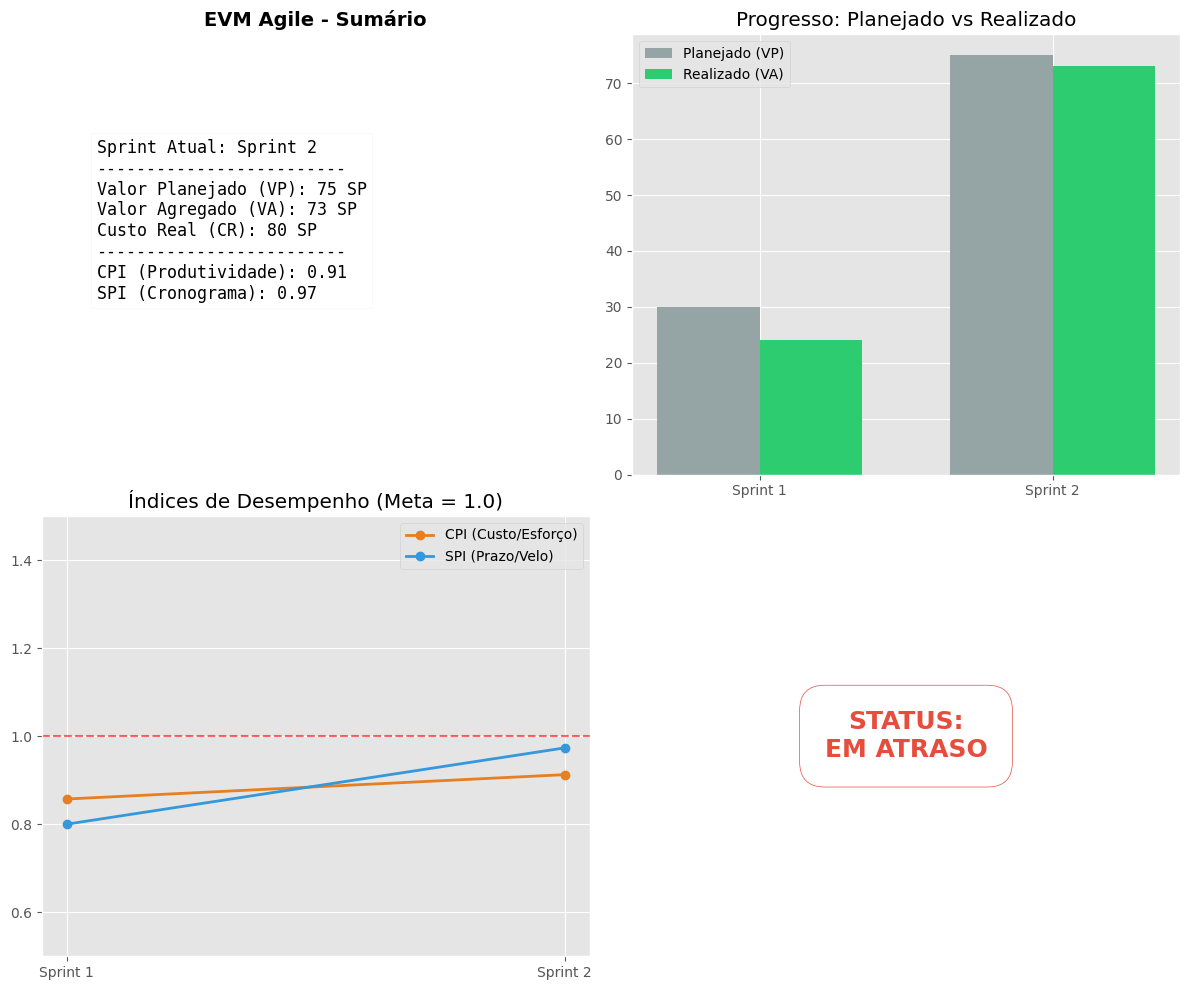

In [8]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = {
    "Sprint": ["Sprint 1", "Sprint 2"],
    "VP": [30, 75],
    "VA": [24, 73],
    "CR": [28, 80]
}

df = pd.DataFrame(data)

df["CPI"] = df["VA"] / df["CR"]
df["SPI"] = df["VA"] / df["VP"]

plt.style.use('ggplot')
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].axis('off')
axs[0, 0].set_title("EVM Agile - Sumário", fontsize=14, fontweight='bold')

last_row = df.iloc[-1]
kpi_text = (
    f"Sprint Atual: {last_row['Sprint']}\n"
    f"{'-'*25}\n"
    f"Valor Planejado (VP): {int(last_row['VP'])} SP\n"
    f"Valor Agregado (VA): {int(last_row['VA'])} SP\n"
    f"Custo Real (CR): {int(last_row['CR'])} SP\n"
    f"{'-'*25}\n"
    f"CPI (Produtividade): {last_row['CPI']:.2f}\n"
    f"SPI (Cronograma): {last_row['SPI']:.2f}"
)
axs[0, 0].text(0.1, 0.4, kpi_text, fontsize=12, family='monospace', bbox=dict(facecolor='white', alpha=0.5))

x = np.arange(len(df["Sprint"]))
width = 0.35
axs[0, 1].bar(x - width/2, df["VP"], width, label="Planejado (VP)", color='#95a5a6')
axs[0, 1].bar(x + width/2, df["VA"], width, label="Realizado (VA)", color='#2ecc71')
axs[0, 1].set_xticks(x)
axs[0, 1].set_xticklabels(df["Sprint"])
axs[0, 1].set_title("Progresso: Planejado vs Realizado")
axs[0, 1].legend()

axs[1, 0].plot(df["Sprint"], df["CPI"], marker='o', label="CPI (Custo/Esforço)", color='#e67e22', linewidth=2)
axs[1, 0].plot(df["Sprint"], df["SPI"], marker='o', label="SPI (Prazo/Velo)", color='#3498db', linewidth=2)
axs[1, 0].axhline(1, color='red', linestyle='--', alpha=0.6)
axs[1, 0].set_ylim(0.5, 1.5)
axs[1, 0].set_title("Índices de Desempenho (Meta = 1.0)")
axs[1, 0].legend()

axs[1, 1].axis('off')
status = "DENTRO DO PRAZO" if last_row["SPI"] >= 1 else "EM ATRASO"
color = "#2ecc71" if last_row["SPI"] >= 1 else "#e74c3c"

axs[1, 1].text(0.5, 0.5, f"STATUS:\n{status}",
              fontsize=18, fontweight='bold', color=color,
              ha='center', va='center', bbox=dict(facecolor='white', edgecolor=color, boxstyle='round,pad=1'))

plt.tight_layout()
plt.show()

## Matriz de Risco (Sprint 2)

A matriz de risco apresenta a distribuição dos riscos identificados no projeto
com base em sua probabilidade de ocorrência e impacto, permitindo priorizar
ações de mitigação.

Cada ponto representa um risco (R01–R12), posicionado conforme seus valores de
probabilidade (eixo Y) e impacto (eixo X). As cores indicam o nível de criticidade:
- Verde: baixo risco
- Amarelo: risco médio
- Vermelho: risco elevado

Observa-se que a maioria dos riscos está concentrada nas faixas de baixo e médio
impacto, indicando um cenário relativamente controlado. No entanto, riscos com
maior criticidade, como aqueles posicionados nas regiões superiores da matriz,
exigem atenção prioritária da equipe.

Essa visualização permite:
- identificar rapidamente os riscos mais críticos
- apoiar decisões de priorização de mitigação
- acompanhar a evolução do perfil de risco ao longo das sprints

A matriz deve ser continuamente atualizada a cada sprint, refletindo mudanças no
contexto do projeto e a efetividade das ações de mitigação adotadas.

In [ ]:
# @title
import plotly.graph_objects as go
import pandas as pd
import numpy as np

riscos_data = [
    ("R01", 4, 4, "Dificuldade com as tecnologias definidas", "Técnico"),
    ("R02", 1, 5, "Saída de algum integrante do projeto", "Gerencial"),
    ("R03", 2, 3, "Divergência nos horários disponíveis dos integrantes", "Organizacional"),
    ("R04", 3, 3, "Alteração no escopo do projeto", "Gerencial"),
    ("R05", 2, 2, "Integrante com problema de saúde", "Externo"),
    ("R06", 2, 5, "Indisponibilidade do cliente ou especialistas", "Externo"),
    ("R07", 2, 3, "Sobrecarga de membros da equipe", "Gerencial"),
    ("R08", 1, 3, "Falha de equipamento", "Externo"),
    ("R09", 1, 3, "Dependência entre atividades", "Organizacional"),
    ("R10", 1, 2, "Problemas com a infraestrutura de rede", "Técnico"),
    ("R11", 1, 4, "Resultados insatisfatórios da solução", "Técnico"),
    ("R12", 2, 4, "Falta de dados adequados para validação", "Externo"),
]

df = pd.DataFrame(riscos_data, columns=["ID", "Probabilidade", "Impacto", "Descrição", "Categoria"])

np.random.seed(101)
df["Prob_J"] = df["Probabilidade"] + np.random.uniform(-0.35, 0.35, len(df))
df["Imp_J"] = df["Impacto"] + np.random.uniform(-0.35, 0.35, len(df))

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df["Imp_J"],
    y=df["Prob_J"],
    mode='markers+text',
    text=df["ID"],
    textposition="middle center",
    marker=dict(size=35, color='white', line=dict(width=2.5, color='black')),
    textfont=dict(color='black', size=10, family="Arial, sans-serif", weight="bold"),
    hovertext=[f"<b>{row['ID']}</b><br>Categoria: {row['Categoria']}<br>Descrição: {row['Descrição']}" for _, row in df.iterrows()],
    hoverinfo="text",
    name="Riscos"
))

fig.update_layout(
    shapes=[
        # Baixo (Verde)
        dict(type="rect", x0=0.5, y0=0.5, x1=2.5, y1=2.5, fillcolor="#27ae60", opacity=0.5, layer="below", line_width=0),
        # Médio (Amarelo)
        dict(type="rect", x0=2.5, y0=0.5, x1=3.5, y1=3.5, fillcolor="#f1c40f", opacity=0.5, layer="below", line_width=0),
        dict(type="rect", x0=0.5, y0=2.5, x1=2.5, y1=3.5, fillcolor="#f1c40f", opacity=0.5, layer="below", line_width=0),
        # Alto (Laranja)
        dict(type="rect", x0=3.5, y0=0.5, x1=4.5, y1=4.5, fillcolor="#e67e22", opacity=0.5, layer="below", line_width=0),
        dict(type="rect", x0=0.5, y0=3.5, x1=3.5, y1=4.5, fillcolor="#e67e22", opacity=0.5, layer="below", line_width=0),
        # Crítico (Vermelho)
        dict(type="rect", x0=4.5, y0=0.5, x1=5.5, y1=5.5, fillcolor="#c0392b", opacity=0.5, layer="below", line_width=0),
        dict(type="rect", x0=0.5, y0=4.5, x1=4.5, y1=5.5, fillcolor="#c0392b", opacity=0.5, layer="below", line_width=0),
    ],
    title="Matriz de Riscos Interativa - RetinaScan (Sprint 2)",
    xaxis=dict(title="Impacto (Gravidade)", range=[0.5, 5.5], tickvals=[1,2,3,4,5], gridcolor='rgba(0,0,0,0.1)'),
    yaxis=dict(title="Probabilidade (Frequência)", range=[0.5, 5.5], tickvals=[1,2,3,4,5], gridcolor='rgba(0,0,0,0.1)'),
    width=850,
    height=750,
    template="plotly_white",
    hoverlabel=dict(bgcolor="white", font_size=12, font_family="Arial")
)

fig.show("png")

In [ ]:
from IPython.display import display, HTML

display(HTML('<iframe src="matriz_riscos.html" width="100%" height="800"></iframe>'))